In [34]:
import os
import sys
from os import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
import json
import argparse
from scipy.optimize import least_squares
import coord_helper as ch
import h5py
import skyfield.api as sf
import importlib
from numpy.linalg import inv
import numbers

In [39]:
day = '07_11'
bits = 1
baseline_idx = 1

config_file_name = f'config_{day}.json'
working_directory = '/project/s/sievers/thomasb/mars_data_24'

In [40]:
with open(f"{working_directory}/{bits}bit/{day}/{config_file_name}", "r") as f:
    config = json.load(f)
    dir_parents = []
    coords = []
    # unpack information from the json file
    # Call get_starting_index for all antennas except reference
    for i, (ant, details) in enumerate(config["antennas"].items()):
        if (i == 0) or (i ==baseline_idx):
            coords.append(details['coordinates'])
            dir_parents.append(details["path"])
    global_start_time = config["correlation"]["start_timestamp"]
    end_t = config["correlation"]["end_timestamp"]
    c_acclen = config["correlation"]["coarse_acclen"]
    v_acclen = config["correlation"]["vis_acclen"]
    visibility_window = config["correlation"]["visibility_window"]
    T_SPECTRA = config["correlation"]["point_PFB"] / config["correlation"]["sample_rate"]

print("Antenna Paths:", dir_parents)
print("Antenna Coordinates:", coords)
print("Visibility Accumulation Length", v_acclen)
print("Coarse Accumulation Length:", c_acclen)
print(global_start_time)

Antenna Paths: ['/project/s/sievers/albatros/mars/202307/baseband/stn_1_central', '/project/s/sievers/albatros/mars/202307/baseband/stn_2_east']
Antenna Coordinates: [[79.41718333333333, -90.76735, 189], [79.41721666666666, -90.75885, 176]]
Visibility Accumulation Length 30000
Coarse Accumulation Length: 1000000
1699335012


In [41]:
ref_coords = coords[0]
a2_coords = coords[1]

ref_path = dir_parents[0]
a2_path = dir_parents[1]

C_T_ACCLEN = c_acclen* T_SPECTRA
V_T_ACCLEN = v_acclen* T_SPECTRA

c_nchunks = int((visibility_window)/C_T_ACCLEN)
v_nchunks = int((visibility_window)/V_T_ACCLEN)

tle_path1 = outils.get_tle_file(global_start_time, "/project/s/sievers/mohanagr/OCOMM_TLES")
#tle_path2 = outils.get_tle_file(global_start_time2, "/project/s/sievers/mohanagr/OCOMM_TLES")


context = [visibility_window, T_SPECTRA, v_acclen, v_nchunks, ref_coords]
print(global_start_time)

1699335012


In [42]:
pulse_list_1 = []

with h5py.File(f'{working_directory}/{bits}bit/{day}/vis_selected_bline_{baseline_idx}_{global_start_time}.h5', 'r') as f:
    for p in f:
        pulse_info = []
        pulse_info.append(p)
        pulse_info.append([f[p].attrs['start_time'], f[p].attrs['end_time'], int(f[p].attrs['global_start_time'])])
        pulse_info.append([int(f[p].attrs['sat']), int(f[p].attrs['chan'])])
        pulse_info.append(f[p].attrs['tle_path'])
        pulse_info.append(f[f'/{p}'][:])
        pulse_list_1.append(pulse_info)
#print(pulse_list_1)
#print("number of pulses present:", len(pulse_list_1))

#note here that they keep the same index label from the earlier full raw data dump
#idea is that this will facilitate tracebacks for debugs
print(pulse_list_1)

[['11_39915', [np.float64(39915.0), np.float64(40037.88), 1699335012], [28654, 1836], '/project/s/sievers/mohanagr/OCOMM_TLES/2023/202311/20231107.txt', array([   0.        ,   -0.26417386,   -0.7408711 ,   -0.80376076,
         -1.10542073,   -1.44641799,   -1.78871617,   -2.16829613,
         -2.38282725,   -2.76156061,   -3.3001369 ,   -3.53458152,
         -3.85445723,   -4.32886608,   -4.6287853 ,   -4.96553118,
         -5.28371008,   -5.71109321,   -6.19332489,   -6.55222263,
         -6.78440402,   -7.06512163,   -7.60252364,   -7.98138179,
         -8.35910755,   -8.4357501 ,   -8.82917463,   -9.27955535,
         -9.7928358 ,  -10.11634028,  -10.31726054,  -10.80547236,
        -11.22820065,  -11.62717364,  -12.07783924,  -12.52214307,
        -12.73909132,  -13.14998026,  -13.62883822,  -13.61583171,
        -14.50942397,  -14.84280322,  -15.20137894,  -15.60639874,
        -16.06135352,  -16.45207483,  -16.82795263,  -17.24603992,
        -17.78321462,  -17.80018616,  -18.2

In [43]:
importlib.reload(ch)

<module 'coord_helper' from '/home/s/sievers/thomasb/albatros_analysis/scripts/orbcomm/fitting/coord_helper.py'>

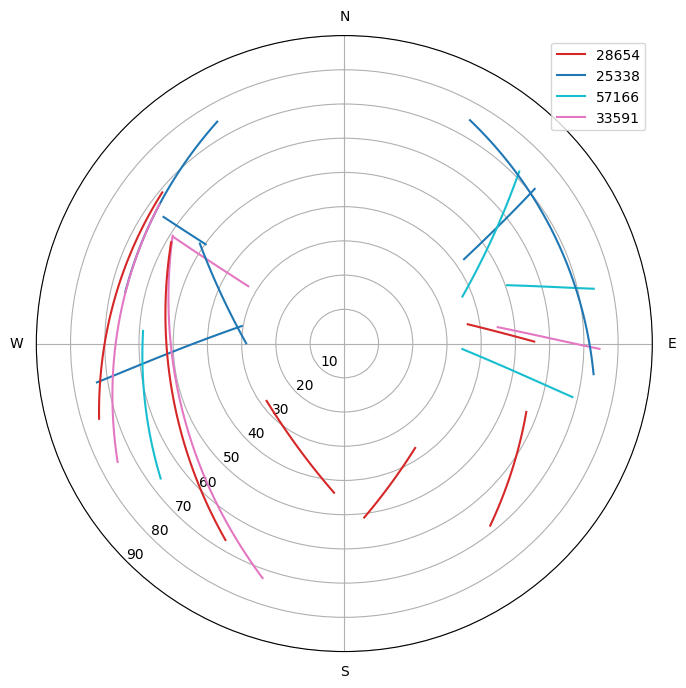

In [44]:
fig = ch.satpass_plotter(pulse_list_1, a2_coords)

In [101]:
importlib.reload(ch)
importlib.reload(outils)

<module 'src.utils.orbcomm_utils' from '/home/s/sievers/thomasb/albatros_analysis/src/utils/orbcomm_utils.py'>

In [77]:
solid = ch.fit_all(a2_coords, ch.pred, pulse_list_1, context)

time taken for one prediction 0.010884523391723633
time taken for one prediction 0.011341333389282227
time taken for one prediction 0.012525796890258789
time taken for one prediction 0.007869482040405273
time taken for one prediction 0.01311349868774414
time taken for one prediction 0.015226364135742188
time taken for one prediction 0.011028528213500977
time taken for one prediction 0.012262105941772461
time taken for one prediction 0.0077915191650390625
time taken for one prediction 0.011063575744628906
time taken for one prediction 0.0089874267578125
time taken for one prediction 0.00791478157043457
time taken for one prediction 0.008529901504516602
time taken for one prediction 0.017635345458984375
time taken for one prediction 0.020029067993164062
time taken for one prediction 0.008393049240112305
time taken for one prediction 0.013158321380615234
time taken for one prediction 0.01049494743347168
time taken for one prediction 0.016720294952392578
time taken for one prediction 0.016

In [78]:
print(solid[0])

[ 79.41722177 -90.75873527 182.67868617]


In [79]:
offsets = []

for i in range(len(pulse_list_1)):
    offsets.append(ch.fit_ds(solid[0], ch.pred, i, pulse_list_1, context)[0])

time taken for one prediction 0.011189699172973633
time taken for one prediction 0.010231256484985352
time taken for one prediction 0.01029658317565918
time taken for one prediction 0.010102033615112305
time taken for one prediction 0.010071992874145508
time taken for one prediction 0.010088920593261719
time taken for one prediction 0.010098934173583984
time taken for one prediction 0.010134220123291016
time taken for one prediction 0.010383844375610352
time taken for one prediction 0.010027885437011719
time taken for one prediction 0.010091066360473633
time taken for one prediction 0.010028362274169922
time taken for one prediction 0.010104179382324219
time taken for one prediction 0.00995635986328125
time taken for one prediction 0.011093616485595703
time taken for one prediction 0.011078834533691406
time taken for one prediction 0.011116504669189453
time taken for one prediction 0.011092662811279297
time taken for one prediction 0.011078834533691406
time taken for one prediction 0.0

In [102]:
print(offsets)
solidlist = solid[0].tolist()

[array([2.]), array([0.71654933]), array([2.]), array([2.]), array([0.46032025]), array([-0.68651898]), array([-0.71445261]), array([0.26832214]), array([1.12214604]), array([0.60719637]), array([2.]), array([-0.98759882]), array([-1.43282944]), array([-2.]), array([2.]), array([-1.71397346]), array([-1.62660435]), array([2.]), array([0.61715998]), array([0.35949649])]


In [103]:
total = ch.fit_given_offsets(solidlist, offsets, pred, pulse_list_1, context)

time taken for one prediction 0.011018753051757812
time taken for one prediction 0.011444091796875
time taken for one prediction 0.012196540832519531
time taken for one prediction 0.007827520370483398
time taken for one prediction 0.01332998275756836
time taken for one prediction 0.015801429748535156
time taken for one prediction 0.011055231094360352
time taken for one prediction 0.012317180633544922
time taken for one prediction 0.007833242416381836
time taken for one prediction 0.011000633239746094
time taken for one prediction 0.008983612060546875
time taken for one prediction 0.00784611701965332
time taken for one prediction 0.008477210998535156
time taken for one prediction 0.017450571060180664
time taken for one prediction 0.01958918571472168
time taken for one prediction 0.008310079574584961
time taken for one prediction 0.013218879699707031
time taken for one prediction 0.010550975799560547
time taken for one prediction 0.016291379928588867
time taken for one prediction 0.01643

In [104]:
print(total[0])

[ 79.41724353 -90.75856543 178.71580775]


In [ ]:
plot = ch.make_coord_plot(a2_coords, )

In [11]:
datapoint = pulse_list_1[19]

print(datapoint[1])
pred = ch.phase_pred(a2_coords, 0, [datapoint], context )
print(len(pred))

print(len(datapoint[4]))
print(np.max(np.abs(pred[:len(datapoint[4])]-datapoint[4])))

[np.float64(82148.728), np.float64(82419.064), np.int64(1699335012)]
time taken for one prediction 0.18975138664245605
555
550
4.886303353800372


In [12]:
without = ch.phase_pred(a2_coords, 0, [datapoint], context)
with_ds = ch.pred(a2_coords, 0, 0, [datapoint], context)

print(len(without))
print(len(with_ds))

print(np.max(np.abs(without[:len(with_ds)] - with_ds[:len(without)])))

time taken for one prediction 0.1858043670654297
time taken for one prediction 0.027172327041625977
555
554
4.447879160807133e-05


In [121]:
print(np.arange(0,10))
print(np.arange(1.5, 11.5))

[0 1 2 3 4 5 6 7 8 9]
[ 1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5]


In [257]:
def res_ds(fit_coords, phase_pred_ds, ds, pulse_idx, data_list, context_list):

    predicted = phase_pred_ds(fit_coords, ds, pulse_idx, data_list, context_list)
    res = data_list[pulse_idx][4] - predicted

    return res

def res_ds_all(fit_coords, ds, phase_pred_ds, data_list, context_list):

    residuals_all = []
    for p_idx, data in enumerate(data_list):

        if isinstance(ds, numbers.Number):
            predicted = phase_pred_ds(fit_coords, ds, p_idx, data_list, context_list)
        else:
            predicted = phase_pred_ds(fit_coords, ds[p_idx], p_idx, data_list, context_list)
        res = data[4] - predicted
        
        residuals_all.append(res.flatten())

    return np.concatenate(residuals_all)

In [258]:
def fit_ds(coords, phase_pred_ds, ds_guess, pulse_idx, data_list, context_list, method='trf'):

    result = least_squares(
        lambda ds: res_ds(coords, phase_pred_ds, ds, pulse_idx, data_list, context_list), 
        0,
        bounds=(-1.0, 1.0),
        method = method
    )
    ds_fit = result.x
    return ds_fit, result


def fit_4p(initial_coords, phase_pred_ds, data_list, context_list, method='trf'):

    n_pulses = len(data_list)
    x0 = np.concatenate([initial_coords, np.zeros(n_pulses)])  # coords + N time offsets


    #clever bounding thing that I cannot claim responsibility for
    coord_bounds = ([-np.inf]*3, [np.inf]*3)
    ds_bounds = ([-1.0]*n_pulses, [1.0]*n_pulses)

    lower = coord_bounds[0] + ds_bounds[0]
    upper = coord_bounds[1] + ds_bounds[1]

    
    result = least_squares(
        lambda x: res_ds_all(x[:3], x[3:], phase_pred_ds, data_list, context_list),
        x0,
        bounds = (lower, upper),
        method=method
    )

    return result.x[:3], result


def fit_4p_fixed(initial_coords, phase_pred_ds, data_list, context_list, method='trf'):

    x0 = np.zeros(4)
    x0[:3] = initial_coords  # coords + single clock offset

    bounds = (
        [-np.inf, -np.inf, -np.inf, -5.0],  # lower
        [ np.inf,  np.inf,  np.inf,  5.0],  # upper
    )

    result = least_squares(
        lambda x: res_ds_all(x[:3], x[3], phase_pred_ds, data_list, context_list),
        x0,
        bounds = bounds,
        method=method
    )

    return result.x, result

In [218]:
res_new = res_ds_all(a2_coords, np.zeros(len(pulse_list_1)), ch.phase_pred_ds, pulse_list_1, context)
res_old = ch.res_all(a2_coords, ch.phase_pred, pulse_list_1, context)

time taken for one prediction 0.012371540069580078
time taken for one prediction 0.017023563385009766
time taken for one prediction 0.016376972198486328
time taken for one prediction 0.014584541320800781
time taken for one prediction 0.01801156997680664
time taken for one prediction 0.00865316390991211
time taken for one prediction 0.017589569091796875
time taken for one prediction 0.016413450241088867
time taken for one prediction 0.01755213737487793
time taken for one prediction 0.020904064178466797
time taken for one prediction 0.017222881317138672
time taken for one prediction 0.028661727905273438
time taken for one prediction 0.009850263595581055
time taken for one prediction 0.010859251022338867
time taken for one prediction 0.023987293243408203
time taken for one prediction 0.013417959213256836
time taken for one prediction 0.028966903686523438
time taken for one prediction 0.017617464065551758
time taken for one prediction 0.011632680892944336
time taken for one prediction 0.02

In [219]:
print(res_old.shape)
print(res_new.shape)

print(np.max(np.abs(res_old - res_new)))

(18030,)
(18030,)
0.00017378743251583728


In [221]:
fit_ds(a2_coords, ch.phase_pred_ds, 0, 2, pulse_list_1, context)

time taken for one prediction 0.023866653442382812
time taken for one prediction 0.01668095588684082
time taken for one prediction 0.016308307647705078
time taken for one prediction 0.01634693145751953
time taken for one prediction 0.016549348831176758
time taken for one prediction 0.01634049415588379
time taken for one prediction 0.0164947509765625
time taken for one prediction 0.016286611557006836
time taken for one prediction 0.01645374298095703
time taken for one prediction 0.01656818389892578
time taken for one prediction 0.016384124755859375
time taken for one prediction 0.016460895538330078


(array([-1.]),
      message: `gtol` termination condition is satisfied.
      success: True
       status: 1
          fun: [ 0.000e+00  2.613e-02 ...  7.685e+00  7.550e+00]
            x: [-1.000e+00]
         cost: 8259.948776941234
          jac: [[ 0.000e+00]
                [ 6.156e-06]
                ...
                [ 3.963e+00]
                [ 3.959e+00]]
         grad: [ 5.767e+03]
   optimality: 6.403039073713167e-13
  active_mask: [-1]
         nfev: 6
         njev: 6)

In [244]:
all_one = fit_4p(a2_coords, ch.phase_pred_ds, pulse_list_1, context)

time taken for one prediction 0.012398958206176758
time taken for one prediction 0.01769709587097168
time taken for one prediction 0.016475915908813477
time taken for one prediction 0.014631986618041992
time taken for one prediction 0.01745438575744629
time taken for one prediction 0.00848245620727539
time taken for one prediction 0.017638683319091797
time taken for one prediction 0.016354084014892578
time taken for one prediction 0.018071651458740234
time taken for one prediction 0.021362781524658203
time taken for one prediction 0.01725625991821289
time taken for one prediction 0.028691530227661133
time taken for one prediction 0.01027536392211914
time taken for one prediction 0.010907173156738281
time taken for one prediction 0.02414679527282715
time taken for one prediction 0.013772010803222656
time taken for one prediction 0.028650522232055664
time taken for one prediction 0.0175626277923584
time taken for one prediction 0.01157379150390625
time taken for one prediction 0.02086091

In [248]:
all_one_single = fit_4p_fixed(a2_coords, ch.phase_pred_ds, pulse_list_1, context)

time taken for one prediction 0.012341737747192383
time taken for one prediction 0.01730942726135254
time taken for one prediction 0.016439199447631836
time taken for one prediction 0.014540433883666992
time taken for one prediction 0.017873525619506836
time taken for one prediction 0.00847768783569336
time taken for one prediction 0.017545461654663086
time taken for one prediction 0.016245365142822266
time taken for one prediction 0.017516613006591797
time taken for one prediction 0.02116680145263672
time taken for one prediction 0.017229557037353516
time taken for one prediction 0.02873706817626953
time taken for one prediction 0.009813308715820312
time taken for one prediction 0.010921716690063477
time taken for one prediction 0.023905515670776367
time taken for one prediction 0.013422966003417969
time taken for one prediction 0.029011011123657227
time taken for one prediction 0.01767563819885254
time taken for one prediction 0.011645078659057617
time taken for one prediction 0.0208

In [249]:
print(all_one_single)

(array([ 79.41721997, -90.75887946, 185.15194891,   2.01183888]),      message: `xtol` termination condition is satisfied.
     success: True
      status: 3
         fun: [ 0.000e+00  6.190e-02 ...  5.251e-01  5.651e-01]
           x: [ 7.942e+01 -9.076e+01  1.852e+02  2.012e+00]
        cost: 18501.124526547806
         jac: [[ 0.000e+00 -0.000e+00  0.000e+00  0.000e+00]
               [-5.895e+02 -5.329e+01  5.959e-04 -1.522e-06]
               ...
               [ 1.067e+05 -1.817e+04 -2.603e-01  1.756e-01]
               [ 1.073e+05 -1.823e+04 -2.606e-01  1.807e-01]]
        grad: [ 3.793e+02 -1.516e+01 -2.317e-01 -1.473e-02]
  optimality: 379.2858374941279
 active_mask: [0 0 0 0]
        nfev: 11
        njev: 7)


In [250]:
all_two_single = fit_4p_fixed(a2_coords, ch.phase_pred_ds, pulse_list_2, context)

time taken for one prediction 0.02367091178894043
time taken for one prediction 0.01831793785095215
time taken for one prediction 0.014003992080688477
time taken for one prediction 0.016552209854125977
time taken for one prediction 0.015822172164916992
time taken for one prediction 0.02432084083557129
time taken for one prediction 0.01373600959777832
time taken for one prediction 0.013809919357299805
time taken for one prediction 0.013944625854492188
time taken for one prediction 0.013784408569335938
time taken for one prediction 0.0073566436767578125
time taken for one prediction 0.026541471481323242
time taken for one prediction 0.021436691284179688
time taken for one prediction 0.020245075225830078
time taken for one prediction 0.015586376190185547
time taken for one prediction 0.012807607650756836
time taken for one prediction 0.01364278793334961
time taken for one prediction 0.022026538848876953
time taken for one prediction 0.018782854080200195
time taken for one prediction 0.013

In [251]:
print(all_two_single)

(array([ 79.41720467, -90.75884337, 187.15818822,   4.99999919]),      message: `xtol` termination condition is satisfied.
     success: True
      status: 3
         fun: [ 0.000e+00  3.258e-02 ...  5.291e+00  5.344e+00]
           x: [ 7.942e+01 -9.076e+01  1.872e+02  5.000e+00]
        cost: 654702.0556221615
         jac: [[ 0.000e+00 -0.000e+00  0.000e+00  0.000e+00]
               [-3.707e+02  3.210e+01 -2.135e-03 -8.905e-04]
               ...
               [ 2.976e+05 -2.799e+04  1.985e-02  1.281e+00]
               [ 2.980e+05 -2.799e+04  2.095e-02  1.286e+00]]
        grad: [ 4.606e+03 -2.152e+02  6.248e+00 -4.834e+03]
  optimality: 4605.626594543457
 active_mask: [0 0 0 0]
        nfev: 14
        njev: 8)


In [15]:
solid1 = ch.fit_all(a2_coords, ch.phase_pred, pulse_list_1, context, tle_path_list=[tle_path1])
solid2 = ch.fit_all(a2_coords, ch.phase_pred, pulse_list_2, context, tle_path_list=[tle_path2])

time taken for one prediction 0.25209808349609375
time taken for one prediction 0.3005797863006592
time taken for one prediction 0.23209476470947266
time taken for one prediction 0.27881669998168945
time taken for one prediction 0.234757661819458
time taken for one prediction 0.2647528648376465
time taken for one prediction 0.3487367630004883
time taken for one prediction 0.2492530345916748
time taken for one prediction 0.3426799774169922
time taken for one prediction 0.2886390686035156
time taken for one prediction 0.35559868812561035
time taken for one prediction 0.3342423439025879
time taken for one prediction 0.3630547523498535
time taken for one prediction 0.2979419231414795
time taken for one prediction 0.2986156940460205
time taken for one prediction 0.38169336318969727
time taken for one prediction 0.32451939582824707
time taken for one prediction 0.4199504852294922
time taken for one prediction 0.32686567306518555
time taken for one prediction 0.3192613124847412
time taken for

In [16]:
print(solid1[0])
print(solid2[0])

[ 79.41722675 -90.7588766  183.32506474]
[ 79.41721575 -90.75882418 181.51778702]


In [18]:
ch.dist_components(solid1[0], solid2[0])

(-1.2244454790430837, 1.0716724794956654, -1.8072777156173743)

In [19]:
pulse_all = pulse_list_1 + pulse_list_2

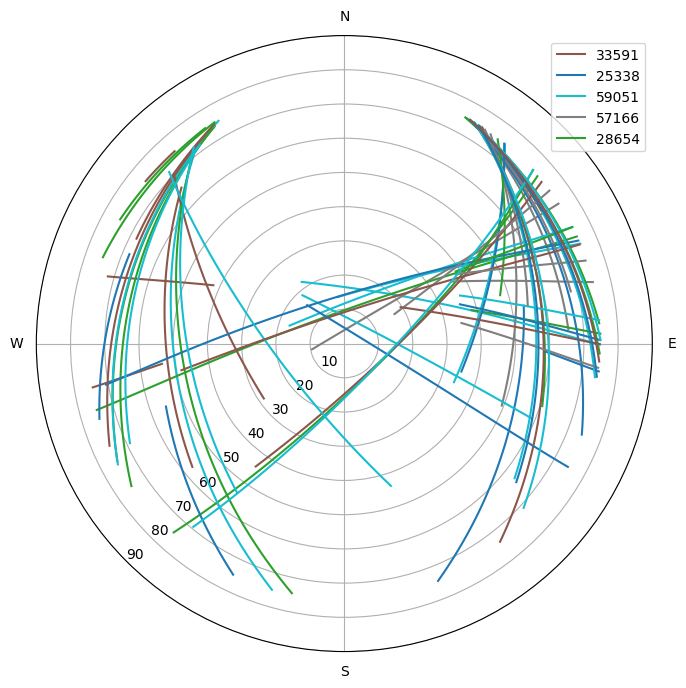

In [20]:
ch.satpass_plotter(pulse_all, a2_coords)


In [23]:
solidall = ch.fit_all(a2_coords, ch.phase_pred, pulse_all, context)[0]

time taken for one prediction 0.1761033535003662
time taken for one prediction 0.2217118740081787
time taken for one prediction 0.2337346076965332
time taken for one prediction 0.19483590126037598
time taken for one prediction 0.2582249641418457
time taken for one prediction 0.1860508918762207
time taken for one prediction 0.34674715995788574
time taken for one prediction 0.24497342109680176
time taken for one prediction 0.24084734916687012
time taken for one prediction 0.267864465713501
time taken for one prediction 0.23662066459655762
time taken for one prediction 0.2567589282989502
time taken for one prediction 0.2689948081970215
time taken for one prediction 0.26690673828125
time taken for one prediction 0.3226282596588135
time taken for one prediction 0.31086230278015137
time taken for one prediction 0.28818750381469727
time taken for one prediction 0.22708678245544434
time taken for one prediction 0.3516366481781006
time taken for one prediction 0.47117066383361816
time taken for

In [24]:
print(solidall)

[ 79.41722209 -90.75884387 182.54822763]


In [26]:
ch.distance_calculator(solidall, solid1[0])

(0.8449893784417437, 0.7768371054695535)

In [27]:
ch.distance_calculator(solidall, solid2[0])

(0.8112322462982784, 1.0304406101478207)

In [33]:
def make_coord_plot(initial_coordinate, tuple_list):

    labels = []
    lats = []
    lons = []

    for pair in tuple_list:
        labels.append(pair[0])
        lats.append(ch.dist_components(initial_coordinates, pair[1])[0])
        lons.append(ch.dist_components(initial_coordinates, pair[1])[1])

    
    plt.scatter(lats, lons)

    # Add labels directly at each point
    for lat, lon, label in zip(lats, lons, labels):
        plt.text(lat, lon, label, fontsize=9, ha='right')

    plt.xlabel("Lon")
    plt.ylabel("Lat")
    plt.grid(True)
    plt.show()


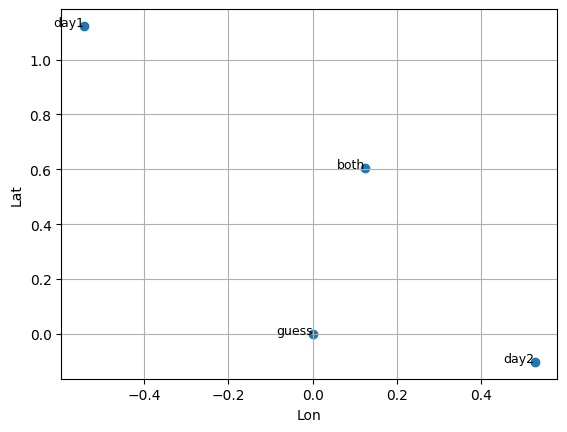

In [29]:
day1_lat_m, day1_lon_m, _ = ch.dist_components(a2_coords, solid1[0])
day2_lat_m, day2_lon_m, _ = ch.dist_components(a2_coords, solid2[0])
all_lat_m, all_lon_m, _ = ch.dist_components(a2_coords, solidall)

lats = [0, day1_lat_m, day2_lat_m, all_lat_m]
lons = [0, day1_lon_m, day2_lon_m, all_lon_m]

labels = ['guess', 'day1', 'day2', 'both']

# Basic scatter plot
plt.scatter(lons, lats)

# Add labels directly at each point
for lon, lat, label in zip(lons, lats, labels):
    plt.text(lon, lat, label, fontsize=9, ha='right')

plt.xlabel("Lon")
plt.ylabel("Lat")
plt.grid(True)
plt.show()
